# Data Exploration

This dataframe explores and visualizes the dataset collected.
Running this notebook requires recorded data, which can be generated by running this example in RECORD mode (see Readme.md).

In [1]:
# set working directoy to root directory of the project
if not "working_directory_corrected" in vars():
    %cd ..
    %cd ..
    %cd ..
    working_directory_corrected = True
    
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from  matplotlib.colors import LinearSegmentedColormap


from examples.gradual_change_scenario.src.gradual_change_scenario import create_gradual_change_scenario

c:\Users\frank\Documents\Research\projects\evohome\examples\gradual_change_scenario
c:\Users\frank\Documents\Research\projects\evohome\examples
c:\Users\frank\Documents\Research\projects\evohome


c:\Users\frank\Documents\Research\projects\evohome\environment\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Data Loading

Below we load the dataset and observe it's general properties.
We also create a second dataset with day-averages to make visualization easier.

In [2]:
scenario = create_gradual_change_scenario()
complete_data = pd.read_pickle("examples/gradual_change_scenario/data/recording.pickle")
complete_data.set_index(pd.DatetimeIndex(complete_data["date"]), inplace=True)
complete_data.drop(labels = ["prediction_time","adaptation_time","prediction_0","prediction_1","prediction_2","prediction_3","prediction_4"], axis = 1, inplace= True)

day_averages = complete_data.resample("D").mean()

room_names = scenario.get_room_names()
nr_rooms = len(room_names)

print(f"The dataframe has {len(complete_data)} samples.")
print(f"The example scenario has {nr_rooms} rooms.")
print("below are five random samples")
day_averages

The dataframe has 432000 samples.
The example scenario has 5 rooms.
below are five random samples


,date,weather,room_0,room_1,room_2,room_3,room_4
date,,,,,,,
2020-01-01,2020-01-01 11:59:30,0.021610,0.0,0.0,0.055556,0.256250,0.437500
2020-01-02,2020-01-02 11:59:30,0.003181,0.0,0.0,0.071528,0.282639,0.395139
2020-01-03,2020-01-03 11:59:30,0.029653,0.0,0.0,0.078472,0.275694,0.395139
2020-01-04,2020-01-04 11:59:30,0.003133,0.0,0.0,0.102778,0.411111,0.486111
2020-01-05,2020-01-05 11:59:30,0.020507,0.0,0.0,0.164583,0.324306,0.511111
...,...,...,...,...,...,...,...
2020-10-22,2020-10-22 11:59:30,0.251837,0.0,0.0,0.097917,0.113889,0.483333
2020-10-23,2020-10-23 11:59:30,0.125688,0.0,0.0,0.142361,0.017361,0.589583
2020-10-24,2020-10-24 11:59:30,0.212963,0.0,0.0,0.134028,0.111806,0.754167


Below we visualize the day-averaged weather quality in the data timeframe

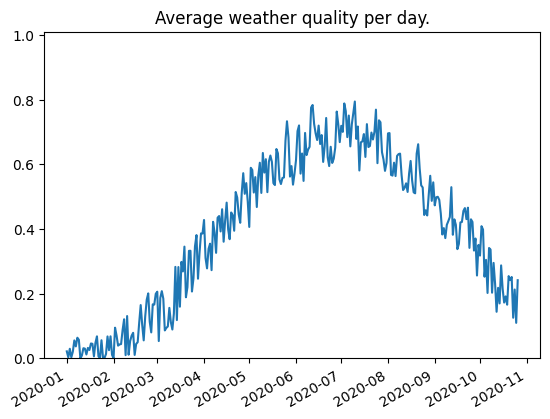

In [3]:

fig, ax = plt.subplots()
ax.plot(day_averages["weather"])
ax.set_title("Average weather quality per day.")
ax.set_ylim([0.0, 1.01])
fig.autofmt_xdate()
plt.show()

## Room Occupation Heatmap

Here we visualize the occupancy of rooms based on a heatmap.

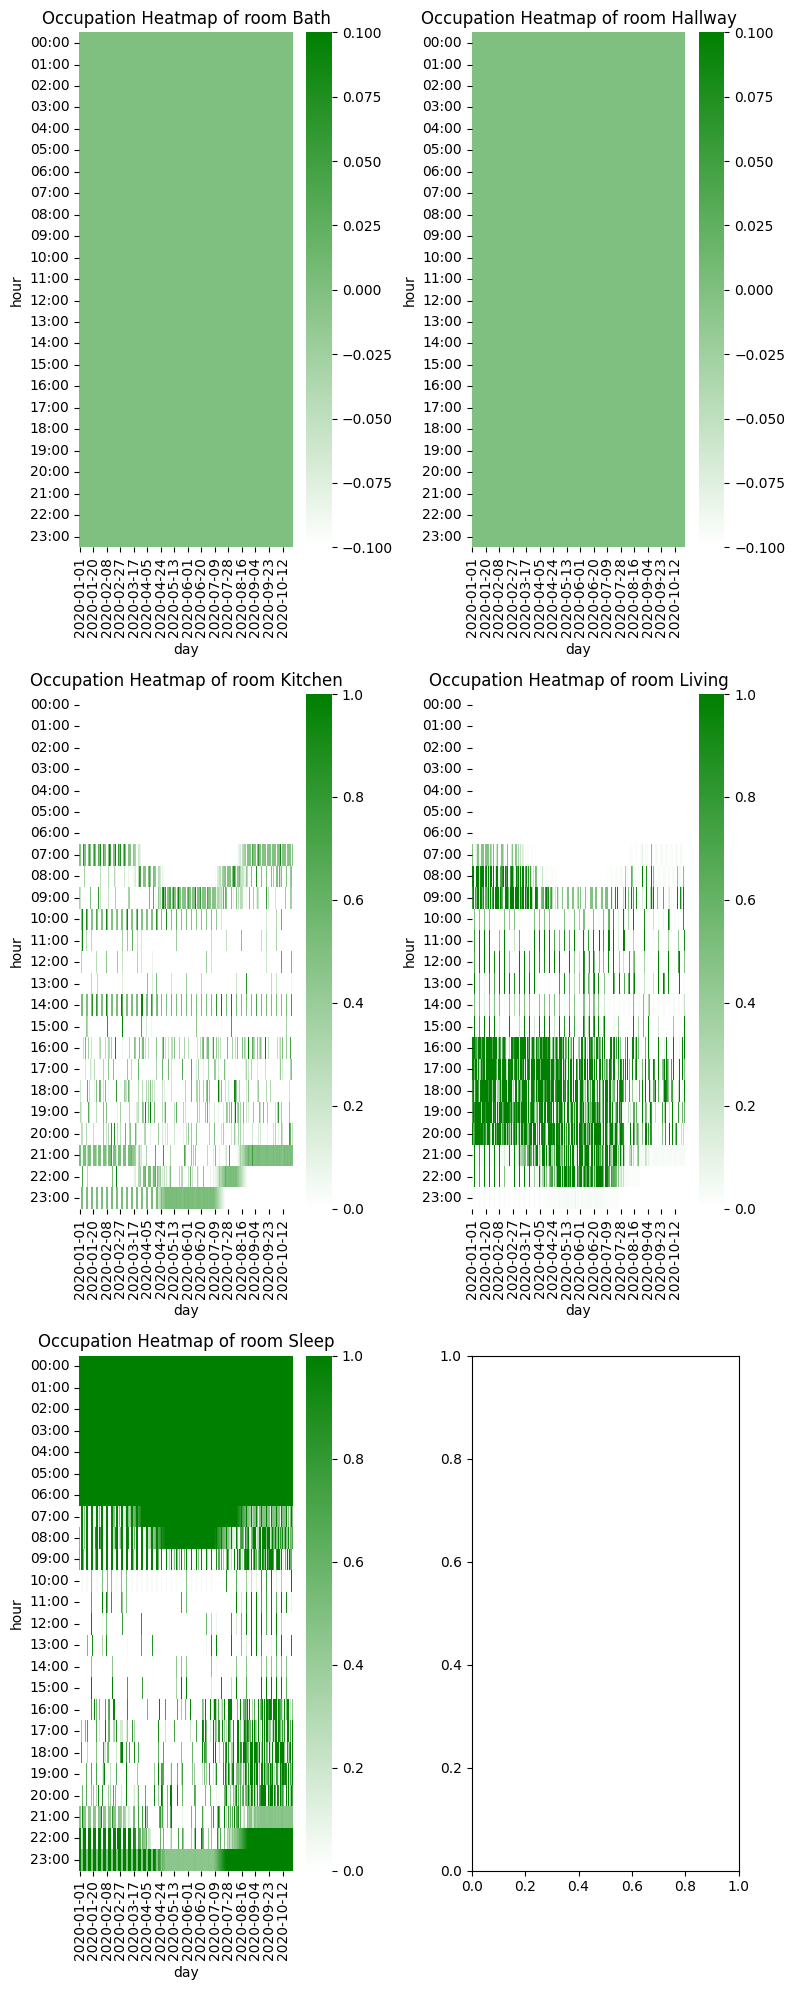

In [5]:


nr_cols = 2
fig, subplots = plt.subplots(ncols= nr_cols,nrows= (nr_rooms+1) //nr_cols, figsize = (8,20))

for room_index in range(nr_rooms):
   ax = subplots[room_index//nr_cols][room_index% nr_cols]
   ax.set_title(f"Occupation Heatmap of room {room_names[room_index]}")
   sns.heatmap(complete_data.groupby([complete_data.date.dt.strftime('%Y-%m-%d'), complete_data.date.dt.strftime('%H:00')])
      [f"room_{room_index}"].mean()
      .rename_axis(index=['day','hour'])
      .unstack(level=0),
      cmap=LinearSegmentedColormap.from_list('rg',["w", "g"], N=256),
      ax=ax
   )

fig.tight_layout()
plt.show()

The heatmaps illustrate the effects of changing sleep times in the scenario. Starting March, the wakeup and sleep times during weekdays begin moving to later, which can be seen in the occupancy data of al rooms, especially for the bedroom. During July and August, both the weekday and weekend sleep and wakeup times gradually move to earlier, which can be seen in the occupancy patterns of all rooms.

The occupancy patterns for living room and bedroom during the day also change starting in July, as studying (which happens in the bedroom area) gradually takes priority from watching TV (which happens in the living room).

## Average Room Occupation
Below we visualize the day-averages of occupation for all rooms in the timeframe.

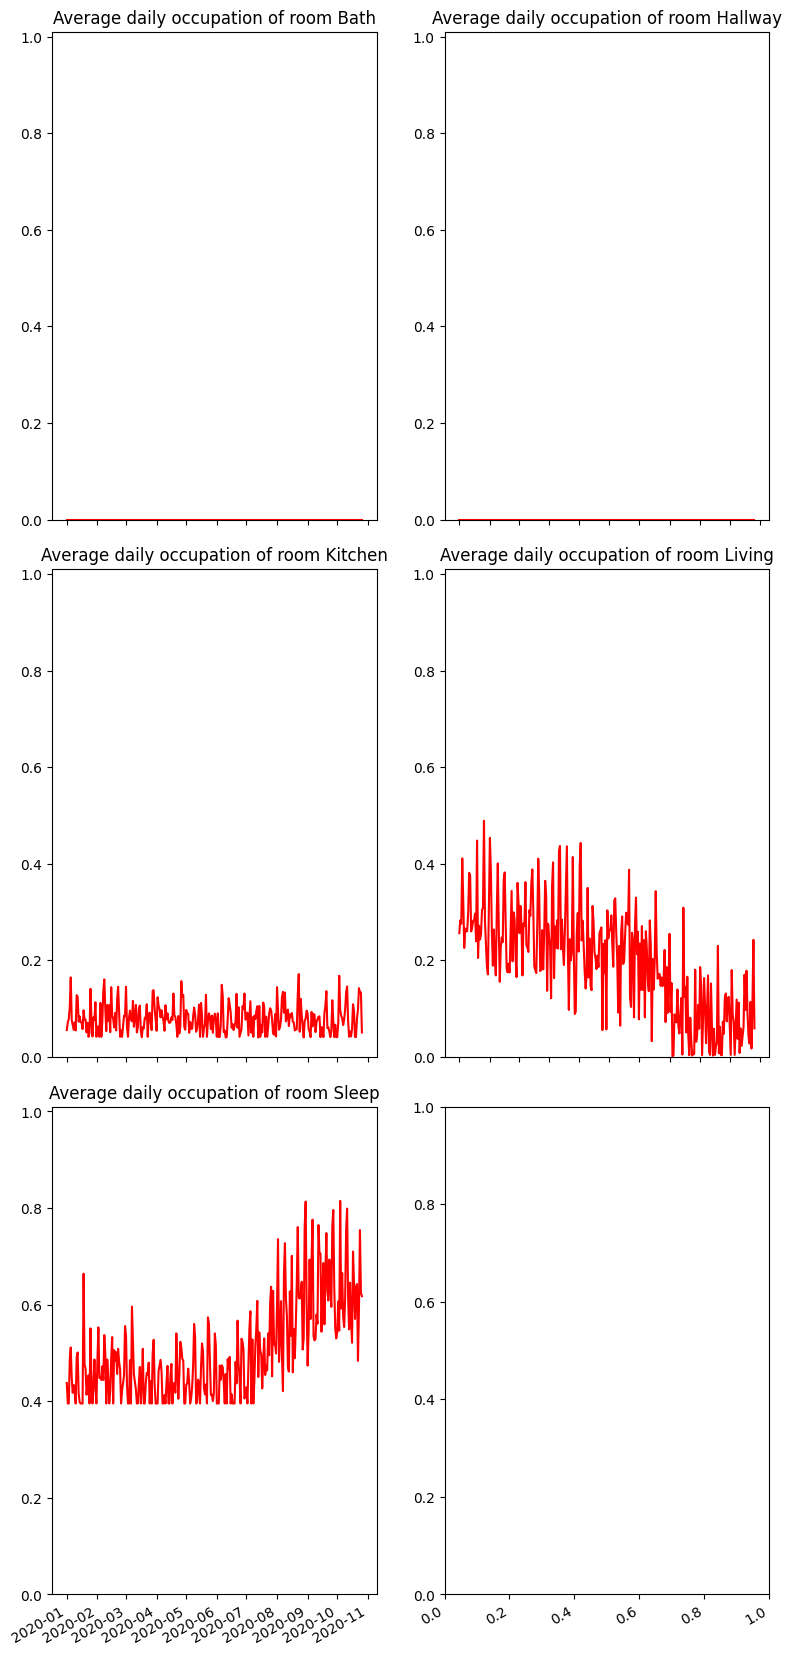

In [4]:

nr_cols = 2
fig, subplots = plt.subplots(ncols= nr_cols,nrows= (nr_rooms+1) //nr_cols, figsize = (8,20))

for room_index in range(nr_rooms):
    ax = subplots[room_index//nr_cols][room_index% nr_cols]
    ax.set_title(f"Average daily occupation of room {room_names[room_index]}")
    ax.plot(day_averages[f"room_{room_index}"],"r-")
    ax.set_ylim([0, 1.01])
    
fig.tight_layout()
fig.autofmt_xdate()
plt.show()

The averages illustrate the effect of changing priorities between studying and watching TV. Starting in July, studying gradually takes precedence and moves focus from the living room to the sleep area.